# Activity 2 Transform & Engineer
### Day 2: Data Cleaning & Preparation (SDA AI Bootcamp)

**Time:** ~30 minutes
**Dataset:** Melbourne Housing Snapshot (continuing from Activity 1)
**Maps to:** Train-Test Split, Scaling, Encoding, Feature Engineering, Feature Selection, Avoiding Leakage

---
### What you'll practice
1. Splitting train/test **before** fitting any transformer (the golden rule)
2. Comparing Min-Max, Standard, and Robust scaling on the same feature
3. Encoding categorical variables, including a real high-cardinality column
4. Engineering new features from a raw date field
5. Dropping a redundant, highly-correlated feature

This notebook is self-contained, it re-loads and re-cleans the data in one condensed cell, so you can run it independently of Activity 1.


## 1. Setup & Recap of Activity 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder

pd.set_option("display.max_columns", 25)
sns.set_style("whitegrid")

DATA_URL = "https://raw.githubusercontent.com/prakharp7/Data-Cleaning-Melbourne-Housing-Dataset/main/Melbourne.csv"
df = pd.read_csv(DATA_URL)

# --- condensed recap of Activity 1's cleaning steps ---
df = df.drop_duplicates()
df = df.drop(columns=["BuildingArea", "YearBuilt"])
df = df[df["Price"].notna()]
for col in ["Car", "Bathroom", "Bedroom2", "Landsize", "Lattitude", "Longtitude"]:
    df[col] = df[col].fillna(df[col].median())
df["CouncilArea"] = df["CouncilArea"].fillna("Unknown")
df = df.dropna()

def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

lo, hi = iqr_bounds(df["Landsize"])
df["Landsize"] = df["Landsize"].clip(lower=lo, upper=hi)

print("Recap complete:", df.shape)
df.head()


Recap complete: (18395, 19)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,03-12-2016,2.5,3067.0,2.0,1.0,1.0,202.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,04-02-2016,2.5,3067.0,2.0,1.0,0.0,156.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,04-03-2017,2.5,3067.0,3.0,2.0,0.0,134.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
5,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,04-03-2017,2.5,3067.0,3.0,2.0,1.0,94.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
6,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,04-06-2016,2.5,3067.0,3.0,1.0,2.0,120.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


## 2. Split FIRST The Golden Rule

Before we scale, encode, or engineer *anything*, we split. This is the single most important habit from Day 2, every transformer we fit from here on will be fit **only on the training set**.

We'll predict `Price` from the other features.

In [2]:
target = "Price"
features = ["Rooms", "Type", "Method", "Distance", "Bedroom2", "Bathroom", "Car",
            "Landsize", "CouncilArea", "Regionname", "Propertycount", "Date", "SellerG"]

X = df[features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (14716, 13)  Test: (3679, 13)


## 3. Scaling Compare the Three Methods

Let's see what each scaler actually does to the same feature (`Landsize`), fit **only on training data**.

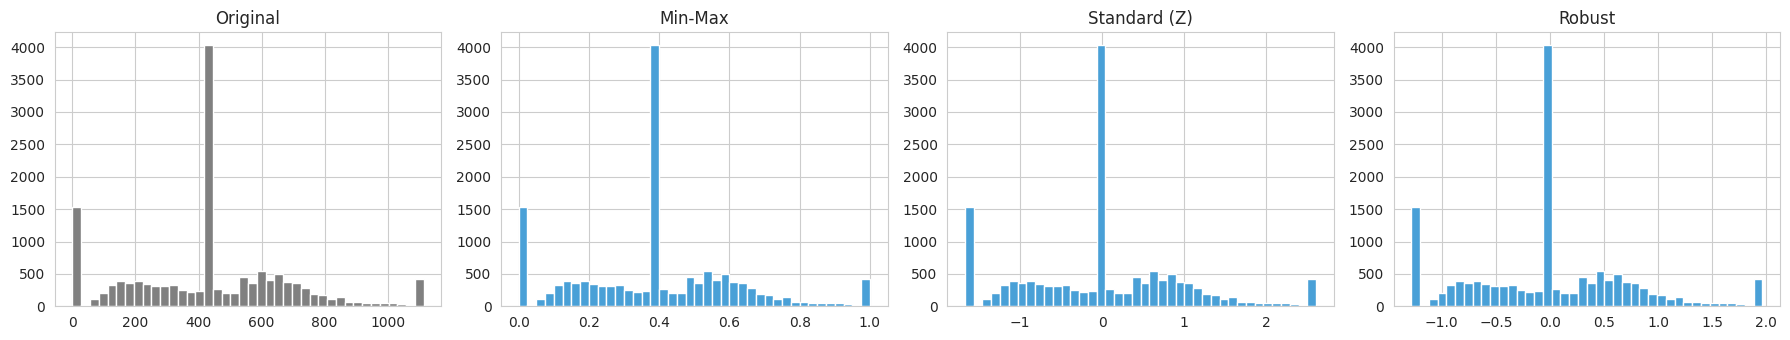

In [3]:
scalers = {
    "Min-Max": MinMaxScaler(),
    "Standard (Z)": StandardScaler(),
    "Robust": RobustScaler(),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
axes[0].hist(X_train["Landsize"], bins=40, color="gray")
axes[0].set_title("Original")

for ax, (name, scaler) in zip(axes[1:], scalers.items()):
    # TODO: fit_transform on X_train, transform only (not fit) on X_test
    scaled_train = scaler.fit_transform(X_train[["Landsize"]])
    ax.hist(scaled_train, bins=40, color="#49A0D7")
    ax.set_title(name)

plt.tight_layout()
plt.show()


### Which scaler would you pick?

`Landsize` still has some legitimately large properties even after capping in Activity 1.

**`# TODO`** Based on the comparison table from lecture, which scaler is the safest default for this feature, and why? Answer in the markdown cell below.

*( RobustScaler
 Because Landsize still has some large values and variations and RobustScaler uses the median and IQR instead of the mean and variance which makes it safe and robust against any remaining outliers.)*

<details>
<summary> Discussion</summary>

**Robust Scaling** is the safest default here — it centers on the median and scales by IQR, so it stays stable even with the residual spread in `Landsize`. Standardization is workable but more outlier-sensitive; Min-Max is the most fragile choice since a single extreme value compresses every other point toward 0.
</details>


## 4. Encoding Categorical Variables

We have a mix of encoding scenarios here:
- `Type` (h/u/t) → low-cardinality nominal → **One-Hot**
- `Regionname` (8 categories) → low-cardinality nominal → **One-Hot**
- `SellerG` → let's check its cardinality first...

In [4]:
print("Unique sellers:", X_train["SellerG"].nunique())
print("Unique council areas:", X_train["CouncilArea"].nunique())


Unique sellers: 282
Unique council areas: 34


330 unique sellers is exactly the "high-cardinality" trap from lecture One-Hot Encoding this would add 330 new sparse columns.

**`# TODO`** Instead, apply **Frequency Encoding**: replace each seller with how often they appear in the training data.

In [5]:
# TODO: compute each seller's frequency in the TRAINING set only, then map it onto both train and test
seller_freq = X_train["SellerG"].value_counts(normalize=True)

X_train["SellerG_freq"] = X_train["SellerG"].map(seller_freq)
X_test["SellerG_freq"] = X_test["SellerG"].map(seller_freq)          # note: still using the TRAIN frequencies
X_test["SellerG_freq"] = X_test["SellerG_freq"].fillna(0)             # unseen sellers in test -> 0

X_train[["SellerG", "SellerG_freq"]].head()


,SellerG,SellerG_freq
20885,Sweeney,0.016105
5419,Barry,0.074205
19750,RT,0.013862
9782,Bells,0.003058
7692,Nelson,0.107570


<details>
<summary>Solution</summary>

```python
X_train["SellerG_freq"] = X_train["SellerG"].map(seller_freq)
```

Notice we computed `seller_freq` from `X_train` only, and reused it (never recomputed) on `X_test` exactly the leakage-avoidance rule from lecture, just applied to encoding instead of scaling.
</details>


In [6]:
# One-Hot encode the low-cardinality columns (Type, Regionname)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(X_train[["Type", "Regionname"]])

train_ohe = pd.DataFrame(ohe.transform(X_train[["Type", "Regionname"]]),
                          columns=ohe.get_feature_names_out(["Type", "Regionname"]),
                          index=X_train.index)
test_ohe = pd.DataFrame(ohe.transform(X_test[["Type", "Regionname"]]),
                         columns=ohe.get_feature_names_out(["Type", "Regionname"]),
                         index=X_test.index)

X_train = pd.concat([X_train, train_ohe], axis=1)
X_test = pd.concat([X_test, test_ohe], axis=1)
print(X_train.shape, X_test.shape)


(14716, 25) (3679, 25)


## 5. Feature Engineering Worked Example

`Date` is a raw string like `"03-09-2016"`. Let's extract structure from it, the same way we did with the `timestamp` example in lecture.

In [7]:
for split_df in (X_train, X_test):
    split_df["Date"] = pd.to_datetime(split_df["Date"], format="%d-%m-%Y")
    # TODO: extract SaleMonth and SaleQuarter from the Date column
    split_df["SaleMonth"] = split_df["Date"].dt.month
    split_df["SaleQuarter"] = split_df["Date"].dt.quarter

X_train[["Date", "SaleMonth", "SaleQuarter"]].head()


,Date,SaleMonth,SaleQuarter
20885,2017-09-09,9,3
5419,2017-02-25,2,1
19750,2017-09-03,9,3
9782,2016-08-13,8,3
7692,2016-09-17,9,3


<details>
<summary>Solution</summary>

```python
split_df["SaleMonth"] = split_df["Date"].dt.month
split_df["SaleQuarter"] = split_df["Date"].dt.quarter
```
</details>

>**Why not `Price_per_Landsize` as a feature?** It's tempting to engineer a ratio like this, but since `Price` is our **target**, any feature built directly from it would leak the answer into the input. Always ask: *"Could I compute this feature without already knowing the label?"*


## 6. Feature Selection Drop a Redundant Feature

`Rooms` and `Bedroom2` are almost certainly measuring close to the same thing. Let's check with a correlation matrix.

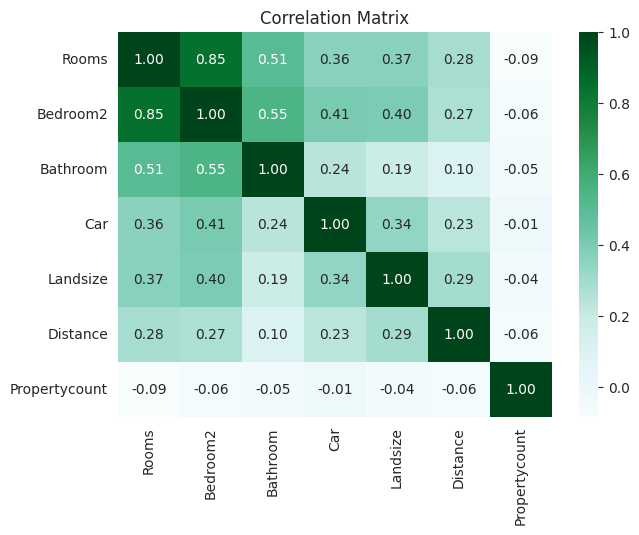

In [8]:
numeric_cols = ["Rooms", "Bedroom2", "Bathroom", "Car", "Landsize", "Distance", "Propertycount"]
corr = X_train[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="BuGn", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


**`# TODO`** Check the actual correlation value between `Rooms` and `Bedroom2` in the matrix above.

You'll find it sits at **~0.85** right at the lecture's threshold, not comfortably past it. This is a realistic judgment call, not a clean-cut case: both columns measure almost the same thing (room count vs. bedroom count), so most practitioners would still drop one to reduce redundancy, even sitting right at the boundary. Decide, then drop **one** of the two columns from both `X_train` and `X_test`.

In [9]:
print("Rooms vs Bedroom2 correlation:", corr.loc["Rooms", "Bedroom2"].round(3))

# TODO: drop the redundant column you decided on, from both X_train and X_test
X_train = X_train.drop(columns=["Bedroom2"])
X_test = X_test.drop(columns=["Bedroom2"])

print("Final feature count:", X_train.shape[1])


Rooms vs Bedroom2 correlation: 0.847
Final feature count: 26


## 7. Checkpoint

Your `X_train` / `X_test` now contain: capped & imputed numeric features, a frequency-encoded high-cardinality column, one-hot encoded regions/types, and engineered date features all fit **only on the training set**.

This is exactly the deliverable the lecture's pipeline diagram promised: **Raw Data → Clean → Split → Scale & Encode → ML-ready.**


In [10]:
X_train.to_csv("melbourne_X_train.csv", index=False)
X_test.to_csv("melbourne_X_test.csv", index=False)
y_train.to_csv("melbourne_y_train.csv", index=False)
y_test.to_csv("melbourne_y_test.csv", index=False)
print("Saved train/test splits.")


Saved train/test splits.


---
## Reflection

1. Why did we compute `seller_freq` using `X_train` only, and reuse it (not recompute it) on `X_test`?
2. What would have happened if we'd One-Hot Encoded `SellerG` instead of frequency-encoding it?
3. Why is a feature like `Price_per_Landsize` dangerous here specifically?

*(1- To prevent data leakage from the test set ensuring our model is fairly evaluated on truly unseen data using only training information

2- It would create hundreds of new sparse columns causing dimensionality explosion which makes the model heavy and less efficient

3- Because it uses the target price directly which leaks the answer into the inputs and causes data leakage instead of real learning
)*
